##  K近邻

#### 距离度量

In [1]:
try:
    from KNearestNeighbors.knn import KNN, L
except ModuleNotFoundError:
    from knn import KNN, L

- p = 1 曼哈顿距离
- p = 2 欧氏距离
- p = inf  闵式距离minkowski_distance 

In [2]:
# L is the educational Minkowski-distance implementation imported above.

In [3]:
# 课本例3.1
x1 = [1, 1]
x2 = [5, 1]
x3 = [4, 4]

In [4]:
# x1, x2
for i in range(1, 5):
    r = { '1-{}'.format(c):L(x1, c, p=i) for c in [x2, x3]}
    print(min(zip(r.values(), r.keys())))

(4.0, '1-[5, 1]')
(4.0, '1-[5, 1]')
(3.7797631496846193, '1-[4, 4]')
(3.5676213450081633, '1-[4, 4]')


python实现，遍历所有数据点，找出n个距离最近的点的分类情况，少数服从多数

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# The hand-written KNN implementation is imported in the first cell.

In [6]:
# data
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['label'] = iris.target
df.columns = ['sepal length', 'sepal width', 'petal length', 'petal width', 'label']
# data = np.array(df.iloc[:100, [0, 1, -1]])

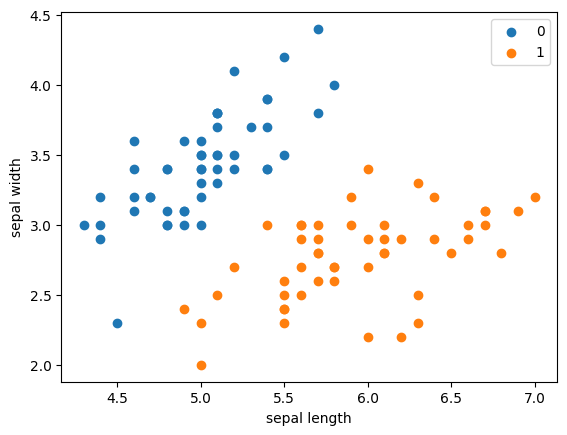

In [7]:
plt.scatter(df[:50]['sepal length'], df[:50]['sepal width'], label='0')
plt.scatter(df[50:100]['sepal length'], df[50:100]['sepal width'], label='1')
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.legend()

In [8]:
data = np.array(df.iloc[:100, [0, 1, -1]])
X, y = data[:,:-1], data[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [9]:
# KNN is imported from KNearestNeighbors/knn.py so tests and this notebook share one implementation.

In [10]:
clf = KNN(X_train, y_train)

In [11]:
clf.score(X_test, y_test)

1.0

In [12]:
test_point = [6.0, 3.0]
print('Test Point: {}'.format(clf.predict(test_point)))

Test Point: 1.0


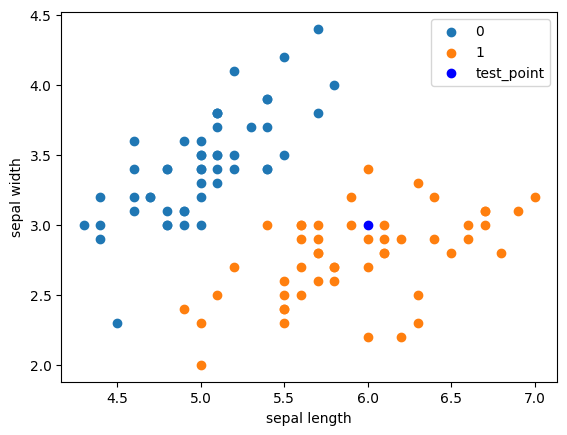

In [13]:
plt.scatter(df[:50]['sepal length'], df[:50]['sepal width'], label='0')
plt.scatter(df[50:100]['sepal length'], df[50:100]['sepal width'], label='1')
plt.plot(test_point[0], test_point[1], 'bo', label='test_point')
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.legend()

# scikitlearn

In [14]:
from sklearn.neighbors import KNeighborsClassifier

In [15]:
clf_sk = KNeighborsClassifier()
clf_sk.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [16]:
clf_sk.score(X_test, y_test)

1.0

### sklearn.neighbors.KNeighborsClassifier

- n_neighbors: 临近点个数
- p: 距离度量
- algorithm: 近邻算法，可选{'auto', 'ball_tree', 'kd_tree', 'brute'}
- weights: 确定近邻的权重